In [63]:
from sklearn import datasets 
from sklearn.svm import LinearSVC
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [64]:
#Load Iris datset

iris = datasets.load_iris()

x = iris["data"][: , (2 , 3)] #Petal length , Petal width
y = (iris["target"] == 2).astype(int) #Iris Virginica

In [65]:
iris_pipeline = Pipeline([
    ("scaler" , StandardScaler()),
    ("linear_svc" , LinearSVC(C = 1 , loss="hinge"))
])

In [66]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [67]:
iris_pipeline.fit(x_scaled , y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [68]:
iris_pipeline.predict([[5 , 4]])

array([1])

In [69]:
#Implementing using SGDclassifier 
from sklearn.linear_model import SGDClassifier

m  = len(x)
c = 0.1

iris_pipeline_1 = Pipeline([
    ("standad_Scaler" , StandardScaler()),
    ("stiochastic " , SGDClassifier(loss= "hinge" , alpha= 1/(m*c)))
])

In [70]:
iris_pipeline_1.fit(x , y)
iris_pipeline_1.predict([[5 , 4]])

array([1])

In [71]:
#non-linear SVM classification
from sklearn.datasets import make_moons 
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

x_1 , y_1 = make_moons(n_samples=100 , random_state=42 , noise= 0.15)

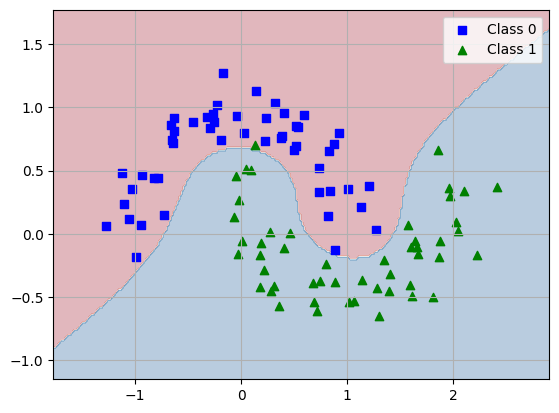

In [113]:
x_min , x_max = x_1[: , 0].min() -0.5 , x_1[: , 0].max() + 0.5
y_min , y_max = x_1[: , 1].min() - 0.5  , x_1[: , 1].max() + 0.5

#Create meshgrid
xx , yy = np.meshgrid(np.arange(x_min , x_max , 0.02) , 
                      np.arange(y_min , y_max , 0.02))

z_1 = moon_pipeline.predict(np.c_[xx.ravel() , yy.ravel()]) #Here we flatten down the 2d xx , yy array into 1D array
z_1 = z_1.reshape(xx.shape) #Here we convert that same 1d array into 2D array

plt.contourf(xx , yy , z_1 , alpha = 0.3 , cmap = "RdBu")
plt.scatter(x_1[y_1 == 0][: , 0] , x_1[y_1 == 0][: , 1] , label = "Class 0" , marker="s" , color = "blue")
plt.scatter(x_1[y_1 == 1][: , 0] , x_1[y_1 == 1][: , 1] , label = "Class 1" , marker="^" , color = "green")
plt.grid()
plt.legend()
plt.show()




In [114]:
moon_pipeline = Pipeline([
    ("scaler" , StandardScaler()),
    ("poly_features" , PolynomialFeatures(degree= 3)),
    ("svm" , LinearSVC(C = 10 , loss= "hinge"))
])

moon_pipeline.fit(x_1 , y_1)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly_features', PolynomialFeatures(degree=3)),
                ('svm', LinearSVC(C=10, loss='hinge'))])

In [115]:
y_pred = moon_pipeline.predict(x_1)

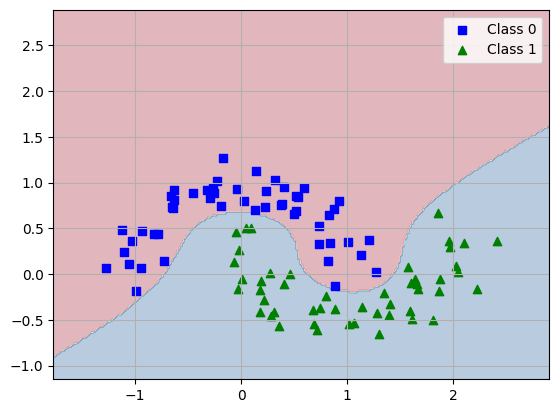

In [116]:
x_min , x_max = x_1[: , 0].min() -0.5 , x_1[: , 0].max() + 0.5
y_min , y_max = x_1[: , 1].min()-0.5 , x_1[: , 0].max() + 0.5

#Meshgrid 
xx , yy = np.meshgrid(np.arange(x_min , x_max , 0.02),
                      np.arange(y_min , y_max , 0.02)) #0.02 means it returns values from x_min to x_max in the spaces of 0.02

Z = moon_pipeline.predict(np.c_[xx.ravel() , yy.ravel()])
Z = Z.reshape(xx.shape) # Plot hannu shape uniform huna parcha tesaile

plt.contourf(xx , yy , Z ,alpha = 0.3 ,cmap = "RdBu")
plt.scatter(x_1[y_pred == 0][: , 0] , x_1[y_pred == 0][: , 1] , label = "Class 0" , marker="s" , color = "blue")
plt.scatter(x_1[y_pred == 1][: , 0] , x_1[y_pred == 1][: , 1] , label = "Class 1" , marker="^" , color = "green")
plt.grid()
plt.legend()
plt.show()


